# Projet ANSSI - Analyse des Vulnérabilités CVE

Ce notebook présente un système complet d'analyse des vulnérabilités de sécurité (CVE) en collectant les données depuis les flux RSS du CERT-FR, puis en enrichissant ces données avec les APIs MITRE et EPSS.

## Objectifs
- Récupérer les alertes et avis de sécurité du CERT-FR
- Extraire les identifiants CVE
- Enrichir les données avec des informations détaillées (scores CVSS, EPSS, types CWE, etc.)
- Consolider et analyser les données
- Générer des visualisations pertinentes

---

##  Imports des bibliothèques nécessaires

Les bibliothèques suivantes sont utilisées pour :
- **feedparser** : Analyser les flux RSS
- **requests** : Effectuer des requêtes HTTP vers les APIs
- **pandas** : Manipuler et analyser les données
- **matplotlib** : Créer des visualisations
- **re** : Utiliser des expressions régulières pour extraire les CVE

In [49]:
import feedparser  
import requests  
import re  
import requests  
from datetime import datetime  
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

---

##  Configuration du projet

Cette section définit toutes les constantes et paramètres utilisés dans le projet :
- URLs des APIs (CERT-FR, MITRE, EPSS)
- Patterns regex pour identifier les CVE
- Seuils de criticité pour l'analyse
- Configuration des graphiques
- Formats de fichiers et de dates

In [50]:
# --- URLS DES APIS ---
RSS_CERT_FR_URL = "https://www.cert.ssi.gouv.fr/avis/feed/"

RSS_CERT_FR_ALERTES_URL = "https://www.cert.ssi.gouv.fr/alerte/feed/"

MITRE_API_URL = "https://cveawg.mitre.org/api/cve/"

EPSS_API_URL = "https://api.first.org/data/v1/epss?cve="

# --- PATTERN REGEX POUR EXTRACTION CVE ---
# Pattern pour identifier les CVE au format CVE-YYYY-NNNNN
CVE_PATTERN = r"CVE-\d{4}-\d{4,7}"

# --- SEUILS DE CRITICITÉ ---
SEUIL_CVSS_CRITIQUE = 7.0

SEUIL_EPSS_CRITIQUE = 0.2

# --- CONFIGURATION GRAPHIQUES ---
# Style matplotlib à utiliser
STYLE_GRAPHIQUES = 'seaborn-v0_8-whitegrid'

# Résolution des graphiques en DPI (points par pouce)
DPI_GRAPHIQUES = 300

# Taille de la figure (largeur, hauteur en pouces)
TAILLE_FIGURE = (16, 12)

# --- NOMS DE FICHIERS ---
# Format du nom de fichier CSV (avec timestamp)
FORMAT_NOM_CSV = "cve_data_{timestamp}.csv"

# Format du timestamp pour les noms de fichiers
FORMAT_TIMESTAMP = "%Y%m%d_%H%M%S"

---

##  ÉTAPE 1 : Collecte des flux RSS du CERT-FR

Cette étape récupère les derniers avis et alertes de sécurité publiés par le CERT-FR via leurs flux RSS.

Les flux RSS contiennent des informations sur les vulnérabilités récemment identifiées.

In [51]:
def recuperer_flux_rss(url=RSS_CERT_FR_URL):
    """
    Récupère et parse le flux RSS du CERT-FR
    
    Paramètre:
        url (str): URL du flux RSS à parser
    
    Retour:
        rss_feed (feedparser.FeedParserDict): Le flux RSS analysé.
    
    """
    rss_feed = feedparser.parse(url)
    return rss_feed


def afficher_flux_rss(rss_feed):
    """
    Affiche les informations du flux RSS
    
    Paramètres:
        rss_feed: Objet feedparser contenant le flux RSS
    """
    print(f"Nombre d'entrées trouvées : {len(rss_feed.entries)}\n")
    
    for entry in rss_feed.entries:
        print("Titre :", entry.title)  
        print("Description:", entry.description)  
        print("Lien :", entry.link)  
        print("Date :", entry.published) 
        print("-" * 80)


def executer_etape_1():
    """
    Fonction principale qui exécute l'étape 1 complète
    
    Retour:
        dict: Dictionnaire contenant les flux RSS des avis et alertes
    """
    print("\n" + "="*80)
    print("ÉTAPE 1 : Récupération des flux RSS du CERT-FR")
    print("="*80)
    
    rss_avis = recuperer_flux_rss(RSS_CERT_FR_URL)
    afficher_flux_rss(rss_avis)
    
    rss_alertes = recuperer_flux_rss(RSS_CERT_FR_ALERTES_URL)
    afficher_flux_rss(rss_alertes)
    
    toutes_entrees = list(rss_avis.entries) + list(rss_alertes.entries)
    
    print("\n" + "="*80)
    print(f"TOTAL : {len(toutes_entrees)} entrées (avis + alertes)")
    print("="*80)
    
    return {
        'avis': rss_avis,
        'alertes': rss_alertes,
        'toutes_entrees': toutes_entrees
    }
flux_data=executer_etape_1()


ÉTAPE 1 : Récupération des flux RSS du CERT-FR
Nombre d'entrées trouvées : 40

Titre : Multiples vulnérabilités dans Trend Micro Apex Central (08 janvier 2026)
Description: De multiples vulnérabilités ont été découvertes dans Trend Micro Apex Central. Elles permettent à un attaquant de provoquer une exécution de code arbitraire à distance et un déni de service à distance.
Lien : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0012/
Date : Thu, 08 Jan 2026 00:00:00 +0000
--------------------------------------------------------------------------------
Titre : Vulnérabilité dans Tenable Nessus Agent (08 janvier 2026)
Description: Une vulnérabilité a été découverte dans Tenable Nessus Agent. Elle permet à un attaquant de provoquer une élévation de privilèges.
Lien : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0013/
Date : Thu, 08 Jan 2026 00:00:00 +0000
--------------------------------------------------------------------------------
Titre : Multiples vulnérabilités dans GitLab (08

---

##  ÉTAPE 2 : Extraction des identifiants CVE

À partir des données collectées, cette étape extrait tous les identifiants CVE mentionnés dans les avis et alertes.

Les CVE sont identifiés par leur format standard : **CVE-[année]-[numéro]**

In [53]:
def recuperer_alerte_json(url):
    """
    Récupère les données JSON d'une alerte CERT-FR
    
    Paramètre:
        url (str): URL de l'API JSON de l'alerte CERT-FR
    
    Retour:
        dict: Dictionnaire Python contenant les données de l'alerte
    """
    response = requests.get(url)
    data = response.json()
    
    return data


def extraire_cve_directs(data):
    """
    Extrait les CVE directement depuis la clé "cves" du JSON
    
    Paramètre:
        data (dict): Dictionnaire contenant les données de l'alerte
    
    Retour:
        list: Liste des CVE référencés (dictionnaires avec "name" et "url")
    """
    ref_cves = list(data.get("cves", []))
    
    return ref_cves


def extraire_cve_regex(data, pattern=CVE_PATTERN):
    """
    Extrait les CVE en utilisant une expression régulière
    
    Paramètres:
        data (dict): Dictionnaire contenant les données de l'alerte
        pattern (str): Expression régulière pour identifier les CVE
    
    Retour:
        list: Liste des identifiants CVE uniques trouvés
    """
    cve_list = list(set(re.findall(pattern, str(data))))
    cve_list.sort()
    
    return cve_list


def afficher_cve_extraits(ref_cves, cve_list, url):
    """
    Affiche les CVE extraits de manière formatée
    
    Paramètres:
        ref_cves (list): CVE référencés directement
        cve_list (list): CVE extraits par regex
        url (str): URL de l'alerte/avis analysé
    """
    print("\n" + "-"*80)
    print(f"Analyse de : {url}")
    print("-"*80)
    
    print(f"CVE référencés dans l'alerte : {len(ref_cves)} CVE trouvés")
    if ref_cves:
        print("Liste des CVE :", ref_cves)
    
    print(f"\nCVE extraits par regex : {len(cve_list)} CVE uniques")
    if cve_list:
        print("Liste des CVE :", cve_list)


def extraire_cve_depuis_flux_rss(url):
    """
    Fonction principale qui exécute l'étape 2 complète
    
    Paramètre:
        url (str): URL de l'alerte à analyser
    
    Retour:
        tuple: (data, ref_cves, cve_list)
            - data: Dictionnaire JSON de l'alerte
            - ref_cves: CVE référencés directement
            - cve_list: CVE extraits par regex
    """
    try:
        data = recuperer_alerte_json(url)
        
        ref_cves = extraire_cve_directs(data)
        cve_list = extraire_cve_regex(data)
        
        afficher_cve_extraits(ref_cves, cve_list, url)
        
        return data, ref_cves, cve_list
    
    except Exception as e:
        print(f"Erreur lors de l'analyse de {url}: {e}")
        return None, [], []


def executer_etape_2(flux_data):
    """
    Extrait les CVE depuis toutes les entrées du flux RSS
    
    Paramètre:
        flux_data (dict ou list): Données du flux RSS (dict avec 'toutes_entrees' ou liste d'entrées)
    
    Retour:
        dict: Dictionnaire contenant :
            - 'resultats': liste de tuples (url, data, ref_cves, cve_list)
            - 'tous_cves': ensemble de tous les CVE uniques trouvés
            - 'nb_alertes_analysees': nombre d'alertes analysées
            - 'cve_type_mapping': dictionnaire {CVE_ID: 'Avis' ou 'Alerte'}
    """
    print("\n" + "="*80)
    print("ÉTAPE 2 : Extraction des CVE depuis toutes les alertes CERT-FR")
    print("="*80)
    
    if isinstance(flux_data, dict):
        entrees = flux_data.get('toutes_entrees', [])
    else:
        entrees = flux_data
    
    resultats = []
    tous_cves = set()
    nb_alertes_analysees = 0
    cve_type_mapping = {}  # Dictionnaire pour stocker CVE_ID -> Type
    
    for entry in entrees:
        url_html = entry.link
        
        # Déterminer le type (Avis ou Alerte)
        if '/avis/' in url_html:
            url_json = url_html.rstrip('/') + '/json/'
            type_source = 'Avis'
        elif '/alerte/' in url_html:
            url_json = url_html.rstrip('/') + '/json/'
            type_source = 'Alerte'
        else:
            print(f"Format d'URL non reconnu : {url_html}")
            continue
        
        data, ref_cves, cve_list = extraire_cve_depuis_flux_rss(url_json)
        
        if data:
            nb_alertes_analysees += 1
            resultats.append((url_json, data, ref_cves, cve_list))
            
            # Associer chaque CVE à son type
            for cve_id in cve_list:
                tous_cves.add(cve_id)
                # Si le CVE existe déjà dans le mapping, on garde la première occurrence
                if cve_id not in cve_type_mapping:
                    cve_type_mapping[cve_id] = type_source
    
    print("\n" + "="*80)
    print(f"RÉSUMÉ DE L'EXTRACTION")
    print("="*80)
    print(f"Alertes analysées : {nb_alertes_analysees}")
    print(f"CVE uniques trouvés : {len(tous_cves)}")
    print(f"Liste des CVE : {sorted(list(tous_cves))}")
    
    return {
        'resultats': resultats,
        'tous_cves': tous_cves,
        'nb_alertes_analysees': nb_alertes_analysees,
        'cve_type_mapping': cve_type_mapping
    }

resultats_extraction = executer_etape_2(flux_data)
cve_list = sorted(list(resultats_extraction['tous_cves']))


ÉTAPE 2 : Extraction des CVE depuis toutes les alertes CERT-FR

--------------------------------------------------------------------------------
Analyse de : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0012/json/
--------------------------------------------------------------------------------
CVE référencés dans l'alerte : 3 CVE trouvés
Liste des CVE : [{'name': 'CVE-2025-69259', 'url': 'https://www.cve.org/CVERecord?id=CVE-2025-69259'}, {'name': 'CVE-2025-69260', 'url': 'https://www.cve.org/CVERecord?id=CVE-2025-69260'}, {'name': 'CVE-2025-69258', 'url': 'https://www.cve.org/CVERecord?id=CVE-2025-69258'}]

CVE extraits par regex : 3 CVE uniques
Liste des CVE : ['CVE-2025-69258', 'CVE-2025-69259', 'CVE-2025-69260']

--------------------------------------------------------------------------------
Analyse de : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0013/json/
--------------------------------------------------------------------------------
CVE référencés dans l'alerte : 

---

##  ÉTAPE 3 : Enrichissement des CVE avec les APIs externes

Pour chaque CVE identifié, cette étape interroge les APIs MITRE et EPSS pour obtenir des informations détaillées.

**Données collectées :**
- **Description** : Détails de la vulnérabilité
- **Score CVSS** : Gravité de la vulnérabilité (0-10)
- **Score EPSS** : Probabilité d'exploitation (0-1)
- **Type CWE** : Classification de la faiblesse
- **Produits affectés** : Liste des éditeurs, produits et versions concernés

In [72]:
def recuperer_donnees_mitre(cve_id):
    """
    Récupère les données d'un CVE depuis l'API MITRE
    
    Paramètre:
        cve_id (str): Identifiant du CVE (ex: CVE-2024-0001)
    
    Retour:
        dict: Dictionnaire contenant toutes les données MITRE du CVE
    """
    url = f"{MITRE_API_URL}{cve_id}"
    
    response = requests.get(url)
    
    data = response.json()
    
    return data


def extraire_description(data):
    """
    Extrait la description d'un CVE depuis les données MITRE
    
    Paramètre:
        data (dict): Données JSON retournées par l'API MITRE
    
    Retour:
        str: Description de la vulnérabilité
    """
    try:
        # Elle se trouve dans containers > cna > descriptions > [0] > value
        description = data["containers"]["cna"]["descriptions"][0]["value"]
        return description
    except (KeyError, IndexError):
        return "Description non disponible"


def extraire_score_cvss(data):
    """
    Extrait le score CVSS d'un CVE
    
    Paramètre:
        data (dict): Données JSON retournées par l'API MITRE
    
    Retour:
        float or str: Score CVSS (0.0-10.0) ou "Non disponible"
    """
    cvss_score = "Non disponible"  
    
    try:
        metrics = data["containers"]["cna"].get("metrics", [])
        
        if metrics:
            if "cvssV3_1" in metrics[0]:
                cvss_score = metrics[0]["cvssV3_1"]["baseScore"]
            elif "cvssV3_0" in metrics[0]:
                cvss_score = metrics[0]["cvssV3_0"]["baseScore"]
    except (KeyError, IndexError):
        pass
    
    return cvss_score


def extraire_cwe(data):
    """
    Extrait le type CWE d'un CVE
    
    Paramètre:
        data (dict): Données JSON retournées par l'API MITRE
    
    Retour:
        tuple: (cwe_id, cwe_description)
    """
    # Le CWE identifie le type de faiblesse 
    cwe = "Non disponible"  
    cwe_desc = "Non disponible"  
    
    try:
        problemtype = data["containers"]["cna"].get("problemTypes", [])
        
        if problemtype and len(problemtype) > 0 and "descriptions" in problemtype[0]:
            cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
            cwe_desc = problemtype[0]["descriptions"][0].get("description", "Non disponible")
    except (KeyError, IndexError):
        pass
    
    return cwe, cwe_desc


def extraire_produits_affectes(data):
    """
    Extrait la liste des produits affectés par un CVE
    
    Paramètre:
        data (dict): Données JSON retournées par l'API MITRE
    
    Retour:
        list: Liste de chaînes formatées "Vendor - Product (versions)"
    """
    affected_products = [] 
    
    try:
        affected = data["containers"]["cna"].get("affected", [])
        
        for product in affected:
            vendor = product.get("vendor", "Inconnu")  
            product_name = product.get("product", "Inconnu")  
            
            versions = [v["version"] for v in product.get("versions", []) 
                       if v.get("status") == "affected"]
            
            print(f"Éditeur : {vendor}, Produit : {product_name}, Versions : {', '.join(versions)}")
            
            affected_products.append(f"{vendor} - {product_name} ({', '.join(versions)})")
    except (KeyError, IndexError):
        pass
    
    return affected_products


def recuperer_score_epss(cve_id):
    """
    Récupère le score EPSS d'un CVE
    
    Paramètre:
        cve_id (str): Identifiant du CVE
    
    Retour:
        float or str: Score EPSS (0.0-1.0) ou "Non disponible"
    """
    # EPSS (Exploit Prediction Scoring System) prédit la probabilité d'exploitation
    epss_score = "Non disponible"  
    
    try:
        url_epss = f"{EPSS_API_URL}{cve_id}"
        
        response_epss = requests.get(url_epss)
        data_epss = response_epss.json()
        
        epss_data = data_epss.get("data", [])
        if epss_data:
            epss_score = float(epss_data[0]["epss"])
            print(f"Score EPSS : {epss_score:.4f} ({epss_score*100:.2f}% de probabilité)")
        else:
            print(f"Aucun score EPSS trouvé pour {cve_id}")
    except Exception as e:
        print(f"Erreur lors de la récupération EPSS pour {cve_id}: {str(e)}")
    
    return epss_score


def enrichir_cve(cve_id, type_source='Non disponible'):
    """
    Enrichit un CVE avec toutes les données disponibles
    
    Paramètres:
        cve_id (str): Identifiant du CVE à enrichir
        type_source (str): Type de source ('Avis' ou 'Alerte')
    
    Retour:
        dict: Dictionnaire contenant toutes les informations du CVE
    """
    print(f"\n--- Traitement de {cve_id} ---")
    
    try:
        data = recuperer_donnees_mitre(cve_id)
        
        description = extraire_description(data)
        cvss_score = extraire_score_cvss(data)
        cwe, cwe_desc = extraire_cwe(data)
        affected_products = extraire_produits_affectes(data)
        
        epss_score = recuperer_score_epss(cve_id)
        
        print(f"CVE : {cve_id}")
        print(f"Description : {description[:200]}...")  # Affiche les 200 premiers caractères
        print(f"Score CVSS : {cvss_score}")
        print(f"Type CWE : {cwe}")
        print(f"CWE Description : {cwe_desc}")
        print(f"Type de source : {type_source}")
        
        cve_info = {
            "CVE_ID": cve_id,  
            "Description": description,  
            "CVSS_Score": cvss_score, 
            "EPSS_Score": epss_score,  
            "CWE_ID": cwe, 
            "CWE_Description": cwe_desc, 
            "Affected_Products": " | ".join(affected_products) if affected_products else "Non disponible", 
            "Type": type_source,
            "Date_Collecte": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        return cve_info
    
    except Exception as e:
        print(f"Erreur lors du traitement de {cve_id}: {str(e)}")
        
        return {
            "CVE_ID": cve_id,
            "Description": "Erreur de récupération",
            "CVSS_Score": "Non disponible",
            "EPSS_Score": "Non disponible",
            "CWE_ID": "Non disponible",
            "CWE_Description": "Non disponible",
            "Affected_Products": "Non disponible",
            "Type": type_source,
            "Date_Collecte": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }


def executer_etape_3(cve_list, cve_type_mapping=None):
    """
    Enrichit tous les CVE de la liste avec les APIs MITRE et EPSS
    
    Paramètres:
        cve_list (list): Liste des identifiants CVE à enrichir
        cve_type_mapping (dict): Dictionnaire {CVE_ID: 'Avis' ou 'Alerte'}
    
    Retour:
        list: Liste de dictionnaires contenant les informations de chaque CVE
    """
    print("\n" + "="*80)
    print("ÉTAPE 3 : Enrichissement des CVE avec les APIs MITRE et EPSS")
    print("="*80)
    
    if cve_type_mapping is None:
        cve_type_mapping = {}
    
    all_cve_data = []
    
    for cve_id in cve_list:
        # Récupérer le type de source depuis le mapping
        type_source = cve_type_mapping.get(cve_id, 'Non disponible')
        cve_info = enrichir_cve(cve_id, type_source)
        all_cve_data.append(cve_info)
    
    return all_cve_data


all_cve_data = executer_etape_3(cve_list, resultats_extraction.get('cve_type_mapping', {}))



ÉTAPE 3 : Enrichissement des CVE avec les APIs MITRE et EPSS

--- Traitement de CVE-2015-20107 ---
Éditeur : n/a, Produit : n/a, Versions : n/a
Score EPSS : 0.0091 (0.91% de probabilité)
CVE : CVE-2015-20107
Description : In Python (aka CPython) up to 3.10.8, the mailcap module does not add escape characters into commands discovered in the system mailcap file. This may allow attackers to inject shell commands into appl...
Score CVSS : Non disponible
Type CWE : Non disponible
CWE Description : n/a
Type de source : Avis

--- Traitement de CVE-2019-20907 ---
Éditeur : n/a, Produit : n/a, Versions : n/a
Score EPSS : 0.0032 (0.32% de probabilité)
CVE : CVE-2019-20907
Description : In Lib/tarfile.py in Python through 3.8.3, an attacker is able to craft a TAR archive leading to an infinite loop when opened by tarfile.open, because _proc_pax lacks header validation....
Score CVSS : Non disponible
Type CWE : Non disponible
CWE Description : n/a
Type de source : Avis

--- Traitement de CVE-2020

---

##  ÉTAPE 4 : Consolidation et sauvegarde des données

Cette étape organise toutes les données collectées dans un DataFrame pandas pour faciliter l'analyse et sauvegarde le résultat dans un fichier CSV.

Le fichier CSV généré peut être réutilisé pour des analyses ultérieures.

In [73]:
def creer_dataframe(all_cve_data):
    """
    Crée un DataFrame pandas à partir des données CVE collectées
    
    Paramètre:
        all_cve_data (list): Liste de dictionnaires contenant les infos CVE
    
    Retour:
        pd.DataFrame: DataFrame structuré avec toutes les données
    """
    df_cve = pd.DataFrame(all_cve_data)
    
    return df_cve


def convertir_scores_numeriques(df_cve):
    """
    Convertit les scores en valeurs numériques pour l'analyse
    
    Paramètre:
        df_cve (pd.DataFrame): DataFrame contenant les données CVE
    
    Retour:
        pd.DataFrame: DataFrame avec colonnes numériques ajoutées
    """
    # Les scores "Non disponible" sont remplacés par NaN (Not a Number)
    df_cve['CVSS_Score_Numeric'] = pd.to_numeric(df_cve['CVSS_Score'], errors='coerce')
    df_cve['EPSS_Score_Numeric'] = pd.to_numeric(df_cve['EPSS_Score'], errors='coerce')
    
    return df_cve


def afficher_statistiques(df_cve):
    """
    Affiche les statistiques descriptives du DataFrame
    
    Paramètre:
        df_cve (pd.DataFrame): DataFrame contenant les données CVE
    """
    print("\n" + "="*80)
    print("ÉTAPE 4 : Consolidation des données dans un DataFrame")
    print("="*80)
    
    print(f"\nNombre total de CVE collectés : {len(df_cve)}")
    print("\nAperçu des données (5 premières lignes) :")
    print(df_cve.head())  
    
    print("\nInformations sur le DataFrame :")
    print(df_cve.info())
    

    print("\nStatistiques sur les scores CVSS :")
    print(df_cve['CVSS_Score_Numeric'].describe())  # Moyenne, médiane, min, max, etc.
    
    print("\nStatistiques sur les scores EPSS :")
    print(df_cve['EPSS_Score_Numeric'].describe())


def sauvegarder_csv(df_cve):
    """
    Sauvegarde le DataFrame en fichier CSV
    
    Paramètre:
        df_cve (pd.DataFrame): DataFrame à sauvegarder
    
    Retour:
        str: Nom du fichier CSV créé
    """
    timestamp = datetime.now().strftime(FORMAT_TIMESTAMP)
    csv_filename = FORMAT_NOM_CSV.format(timestamp=timestamp)
    
    df_cve.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"\nDonnées sauvegardées dans le fichier : {csv_filename}")
    
    return csv_filename


def executer_etape_4(all_cve_data):
    """
    Fonction principale qui exécute l'étape 4 complète
    
    Paramètre:
        all_cve_data (list): Liste des dictionnaires CVE
    
    Retour:
        tuple: (df_cve, csv_filename)
    """
    df_cve = creer_dataframe(all_cve_data)
    
    df_cve = convertir_scores_numeriques(df_cve)
    
    afficher_statistiques(df_cve)
    
    csv_filename = sauvegarder_csv(df_cve)
    
    return df_cve, csv_filename

df_cve, csv_filename = executer_etape_4(all_cve_data)


ÉTAPE 4 : Consolidation des données dans un DataFrame

Nombre total de CVE collectés : 456

Aperçu des données (5 premières lignes) :
           CVE_ID                                        Description  \
0  CVE-2015-20107  In Python (aka CPython) up to 3.10.8, the mail...   
1  CVE-2019-20907  In Lib/tarfile.py in Python through 3.8.3, an ...   
2  CVE-2020-26116  http.client in Python 3.x before 3.5.10, 3.6.x...   
3   CVE-2020-8492  Python 2.7 through 2.7.17, 3.5 through 3.5.9, ...   
4   CVE-2021-3177  Python 3.x through 3.9.1 has a buffer overflow...   

       CVSS_Score EPSS_Score          CWE_ID CWE_Description  \
0  Non disponible    0.00905  Non disponible             n/a   
1  Non disponible    0.00323  Non disponible             n/a   
2  Non disponible    0.00832  Non disponible             n/a   
3  Non disponible    0.03512  Non disponible             n/a   
4  Non disponible    0.00074  Non disponible             n/a   

  Affected_Products  Type        Date_Collecte 

---

##  ÉTAPE 5 : Préparation des visualisations

Cette section prépare les données et configure l'environnement pour générer des graphiques d'analyse.

La préparation des données est essentielle pour obtenir des visualisations cohérentes et informatives.

In [74]:
# ==================== FONCTIONS UTILITAIRES POUR LES GRAPHIQUES ====================

def configurer_style_graphiques():
    """Configure le style matplotlib pour tous les graphiques"""
    plt.style.use(STYLE_GRAPHIQUES)
    plt.rcParams["figure.figsize"] = (10, 6)


def score_cvss(score):
    """Convertit un score CVSS numérique en niveau de sévérité."""
    if score in (None, "Non disponible") or pd.isna(score):
        return "Non disponible"
    try:
        score = float(score)
    except (ValueError, TypeError):
        return "Non disponible"

    if score >= 9.0:
        return "Critique"
    if score >= 7.0:
        return "Élevée"
    if score >= 4.0:
        return "Moyenne"
    if score >= 0.1:
        return "Faible"
    return "Aucune"


def top_n_series(s: pd.Series, n=10, other_label="Autres"):
    """Retourne les n valeurs les plus fréquentes avec un groupe 'Autres'."""
    s = s.dropna()
    s = s[s != "Non disponible"]
    vc = s.value_counts()
    if len(vc) <= n:
        return vc
    head = vc.head(n)
    tail_sum = vc.iloc[n:].sum()
    return pd.concat([head, pd.Series({other_label: tail_sum})])


def explode_multi_col(df_in: pd.DataFrame, col: str, sep=", "):
    """Éclate une colonne contenant des valeurs multiples séparées."""
    tmp = df_in.copy()
    tmp[col] = tmp[col].fillna("Non disponible").astype(str)
    tmp = tmp[tmp[col] != "Non disponible"]
    tmp[col] = tmp[col].str.split(sep)
    tmp = tmp.explode(col)
    tmp[col] = tmp[col].astype(str).str.strip()
    tmp = tmp[(tmp[col] != "") & (tmp[col] != "Non disponible")]
    return tmp


def preparer_donnees(df_cve):
    """Prépare et nettoie les données pour les visualisations"""
    df_plot = df_cve.copy()
    
    if 'CVSS_Score_Numeric' not in df_plot.columns:
        cvss_col = 'CVSS_Score' if 'CVSS_Score' in df_plot.columns else 'Score CVSS'
        df_plot["CVSS_Score_Numeric"] = pd.to_numeric(
            df_plot.get(cvss_col, "Non disponible").replace("Non disponible", np.nan), 
            errors="coerce"
        )
    
    if 'EPSS_Score_Numeric' not in df_plot.columns:
        epss_col = 'EPSS_Score' if 'EPSS_Score' in df_plot.columns else 'EPSS'
        df_plot["EPSS_Score_Numeric"] = pd.to_numeric(
            df_plot.get(epss_col, "Non disponible").replace("Non disponible", np.nan), 
            errors="coerce"
        )
    
    if 'CVSS_Severity' not in df_plot.columns:
        sev_col = 'Sévérité CVSS' if 'Sévérité CVSS' in df_plot.columns else None
        if sev_col and sev_col in df_plot.columns:
            df_plot['CVSS_Severity'] = df_plot[sev_col]
        else:
            df_plot['CVSS_Severity'] = df_plot['CVSS_Score_Numeric'].apply(score_cvss)
    
    if 'CWE_ID' not in df_plot.columns:
        df_plot['CWE_ID'] = df_plot.get('Type CWE', 'Non disponible')
    
    # Extraction du Vendor et Product depuis Affected_Products
    if 'Vendor' not in df_plot.columns and 'Affected_Products' in df_plot.columns:
        df_plot['Vendor'] = df_plot['Affected_Products'].apply(
            lambda x: x.split(' - ')[0] if isinstance(x, str) and ' - ' in x else 'Non disponible'
        )
    elif 'Vendor' not in df_plot.columns:
        df_plot['Vendor'] = 'Non disponible'
    
    if 'Product' not in df_plot.columns and 'Affected_Products' in df_plot.columns:
        df_plot['Product'] = df_plot['Affected_Products'].apply(
            lambda x: x.split(' - ')[1].split(' (')[0] if isinstance(x, str) and ' - ' in x and ' (' in x else 'Non disponible'
        )
    elif 'Product' not in df_plot.columns:
        df_plot['Product'] = 'Non disponible'
    
    if 'Affected_Versions' not in df_plot.columns and 'Affected_Products' in df_plot.columns:
        df_plot['Affected_Versions'] = df_plot['Affected_Products'].apply(
            lambda x: x.split('(')[1].rstrip(')') if isinstance(x, str) and '(' in x else 'Non disponible'
        )
    elif 'Affected_Versions' not in df_plot.columns:
        df_plot['Affected_Versions'] = 'Non disponible'
    
    if 'Type' not in df_plot.columns:
        # Si Type n'existe pas, on ne peut pas le créer car l'info n'a pas été collectée
        # On laisse la colonne absente pour que les graphiques qui en ont besoin gèrent l'erreur
        pass
    
    if 'CVE_ID' not in df_plot.columns:
        df_plot['CVE_ID'] = df_plot.get('CVE_ID', 'Non disponible')
    
    # Extraction de la date depuis Date_Collecte
    if 'Date_Parsed' not in df_plot.columns:
        date_col = 'Date' if 'Date' in df_plot.columns else 'Date_Collecte' if 'Date_Collecte' in df_plot.columns else None
        if date_col:
            df_plot["Date_Parsed"] = pd.to_datetime(
                df_plot[date_col], errors="coerce", utc=True
            )
            if df_plot["Date_Parsed"].dt.tz is not None:
                df_plot["Date_Parsed"] = df_plot["Date_Parsed"].dt.tz_convert(None)
    
    return df_plot


# Configuration initiale
configurer_style_graphiques()
timestamp = datetime.now().strftime(FORMAT_TIMESTAMP)
print(f"Configuration des graphiques terminée. Timestamp : {timestamp}")

Configuration des graphiques terminée. Timestamp : 20260115_202935


---

##  Visualisations des données

Les graphiques suivants permettent d'analyser les vulnérabilités sous différents angles.

---

###  Graphique 1 : Distribution des scores CVSS

Histogramme montrant la répartition des vulnérabilités selon leur score CVSS (de 0 à 10).
Plus le score est élevé, plus la vulnérabilité est grave.

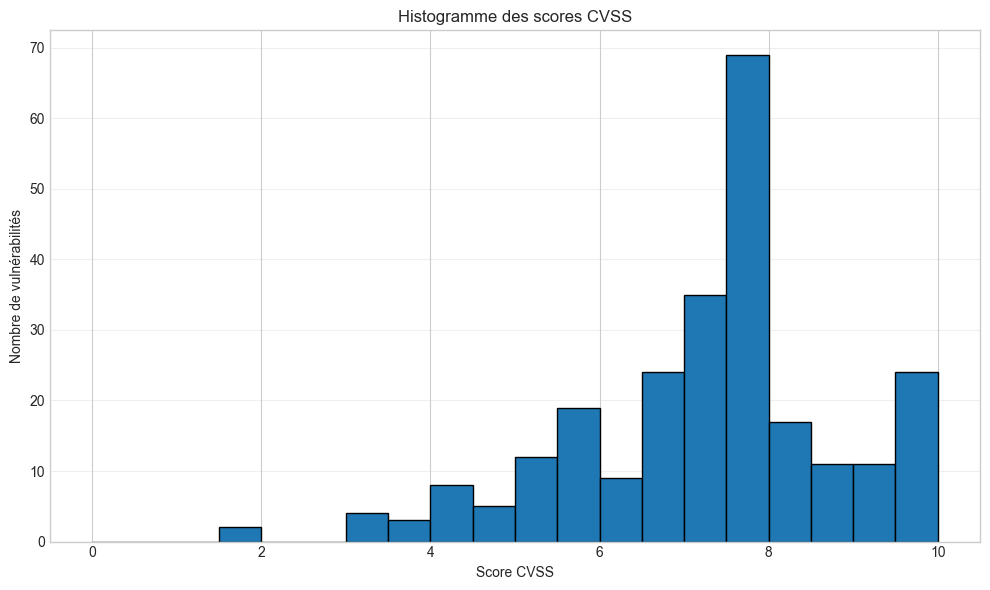

In [75]:
# Préparation des données pour les graphiques
df_plot = preparer_donnees(df_cve)

# Graphique 1 : Histogramme des scores CVSS
cvss_vals = df_plot["CVSS_Score_Numeric"].dropna()
if len(cvss_vals) > 0:
    plt.figure()
    plt.hist(cvss_vals, bins=np.arange(0, 10.5, 0.5), edgecolor="black")
    plt.title("Histogramme des scores CVSS")
    plt.xlabel("Score CVSS")
    plt.ylabel("Nombre de vulnérabilités")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_01_histogramme_cvss_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée CVSS disponible")

---

###  Graphique 2 : Répartition par niveau de sévérité

Diagramme en barres classifiant les vulnérabilités selon leur niveau de sévérité :
- **Critique** : CVSS ≥ 9.0
- **Élevée** : CVSS ≥ 7.0
- **Moyenne** : CVSS ≥ 4.0
- **Faible** : CVSS < 4.0

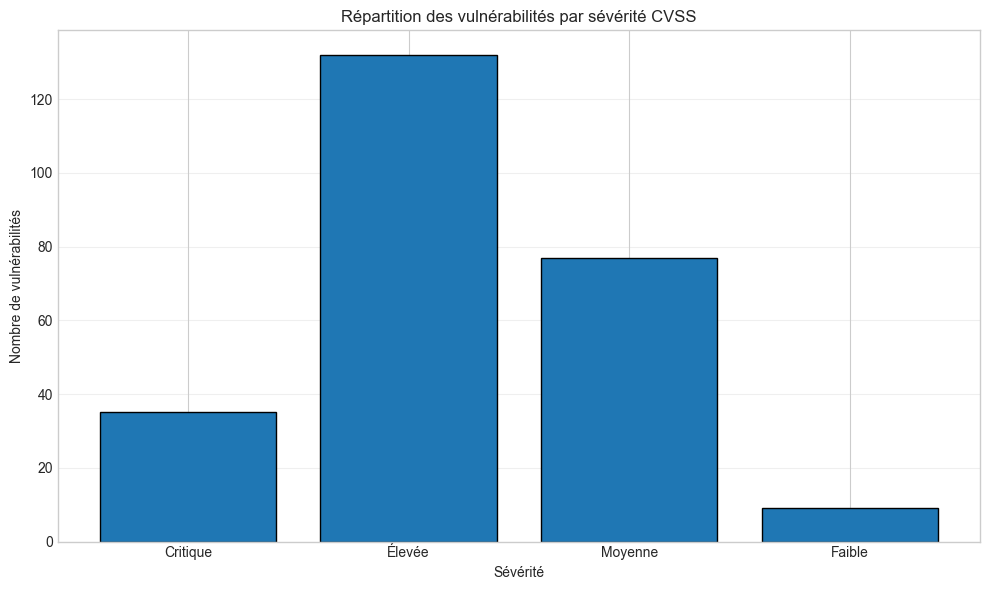

In [76]:
# Graphique 2 : Répartition par sévérité CVSS
sev_counts = df_plot["CVSS_Severity"].replace("Non disponible", np.nan).dropna().value_counts()
if len(sev_counts) > 0:
    order = ["Critique", "Élevée", "Moyenne", "Faible", "Aucune"]
    sev_counts = sev_counts.reindex([x for x in order if x in sev_counts.index]).fillna(0)
    plt.figure()
    plt.bar(sev_counts.index, sev_counts.values, edgecolor="black")
    plt.title("Répartition des vulnérabilités par sévérité CVSS")
    plt.xlabel("Sévérité")
    plt.ylabel("Nombre de vulnérabilités")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_02_severite_cvss_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée de sévérité disponible")

---

###  Graphique 3 : Types de vulnérabilités (CWE)

Diagramme circulaire montrant la répartition des vulnérabilités par type CWE (Common Weakness Enumeration).
Les CWE identifient les types de faiblesses de sécurité (ex : injection SQL, buffer overflow, etc.).

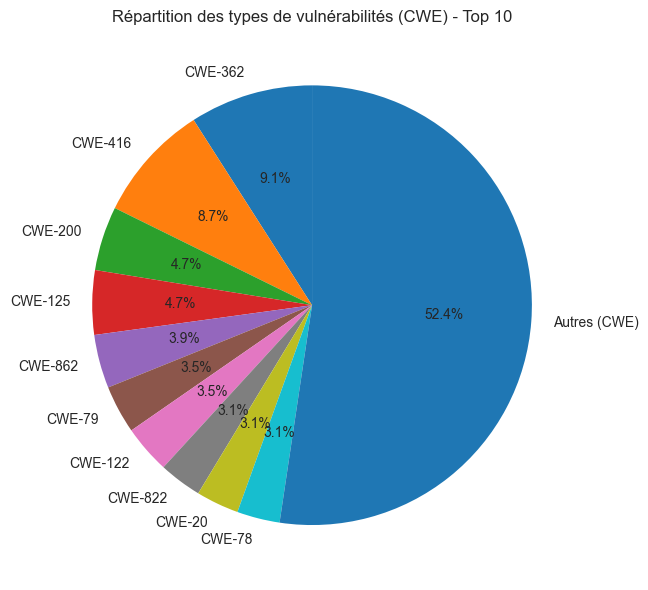

In [77]:
# Graphique 3 : Diagramme circulaire des types de vulnérabilités (CWE)
cwe_counts = top_n_series(df_plot["CWE_ID"], n=10, other_label="Autres (CWE)")
if len(cwe_counts) > 0:
    plt.figure()
    plt.pie(cwe_counts.values, labels=cwe_counts.index, autopct="%1.1f%%", startangle=90)
    plt.title("Répartition des types de vulnérabilités (CWE) - Top 10")
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_03_diagramme_cwe_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée CWE disponible")

---

###  Graphique 4 : Courbe des scores EPSS

Courbe montrant les scores EPSS (Exploit Prediction Scoring System) triés par ordre décroissant.
Le score EPSS prédit la probabilité qu'une vulnérabilité soit exploitée (0 = peu probable, 1 = très probable).

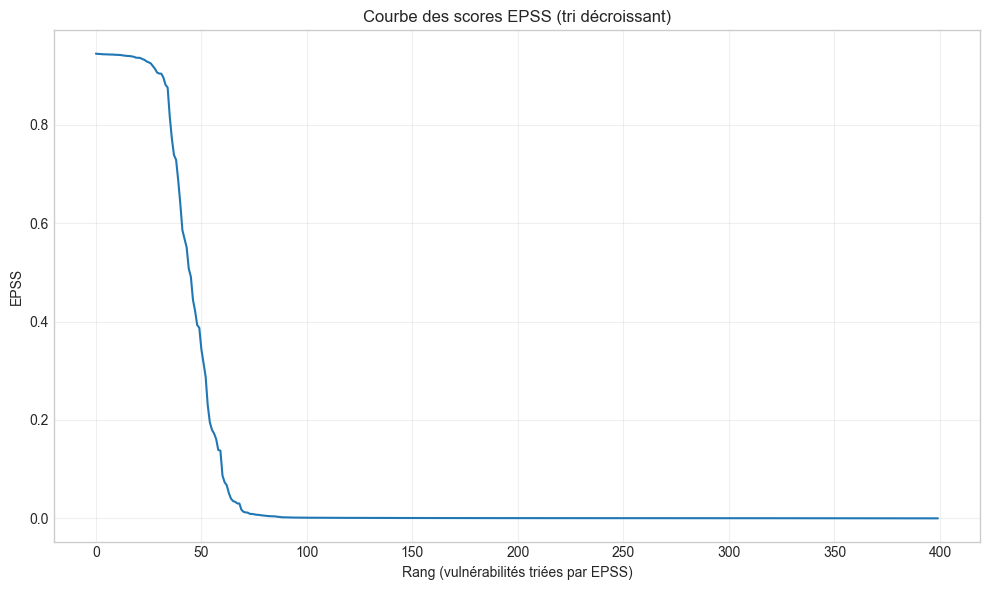

In [78]:
# Graphique 4 : Courbe des scores EPSS
epss_vals = df_plot["EPSS_Score_Numeric"].dropna().sort_values(ascending=False).reset_index(drop=True)
if len(epss_vals) > 0:
    plt.figure()
    plt.plot(epss_vals.values)
    plt.title("Courbe des scores EPSS (tri décroissant)")
    plt.xlabel("Rang (vulnérabilités triées par EPSS)")
    plt.ylabel("EPSS")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_04_courbe_epss_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée EPSS disponible")

---

###  Graphique 5 : Top 15 des éditeurs les plus affectés

Diagramme en barres horizontales montrant les éditeurs (vendors) dont les produits sont le plus souvent mentionnés dans les vulnérabilités.

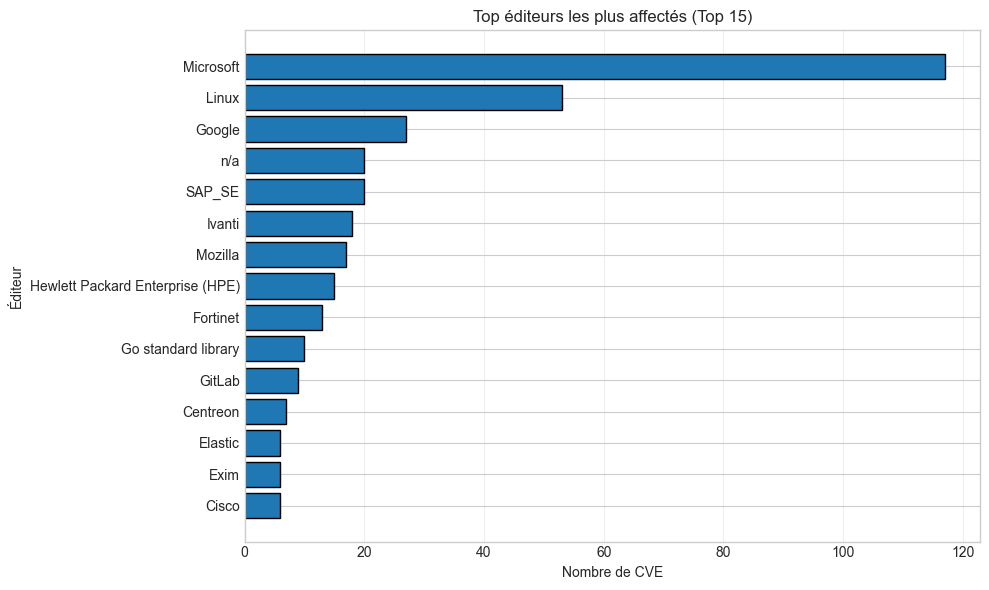

In [79]:
# Graphique 5 : Top éditeurs les plus affectés
df_vendors = explode_multi_col(df_plot, "Vendor")
vendor_counts = df_vendors["Vendor"].value_counts().head(15)
if len(vendor_counts) > 0:
    plt.figure()
    plt.barh(vendor_counts.index[::-1], vendor_counts.values[::-1], edgecolor="black")
    plt.title("Top éditeurs les plus affectés (Top 15)")
    plt.xlabel("Nombre de CVE")
    plt.ylabel("Éditeur")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_05_top_editeurs_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée d'éditeur disponible")

---

###  Graphique 6 : Top 15 des produits les plus affectés

Diagramme en barres horizontales identifiant les produits logiciels les plus vulnérables.

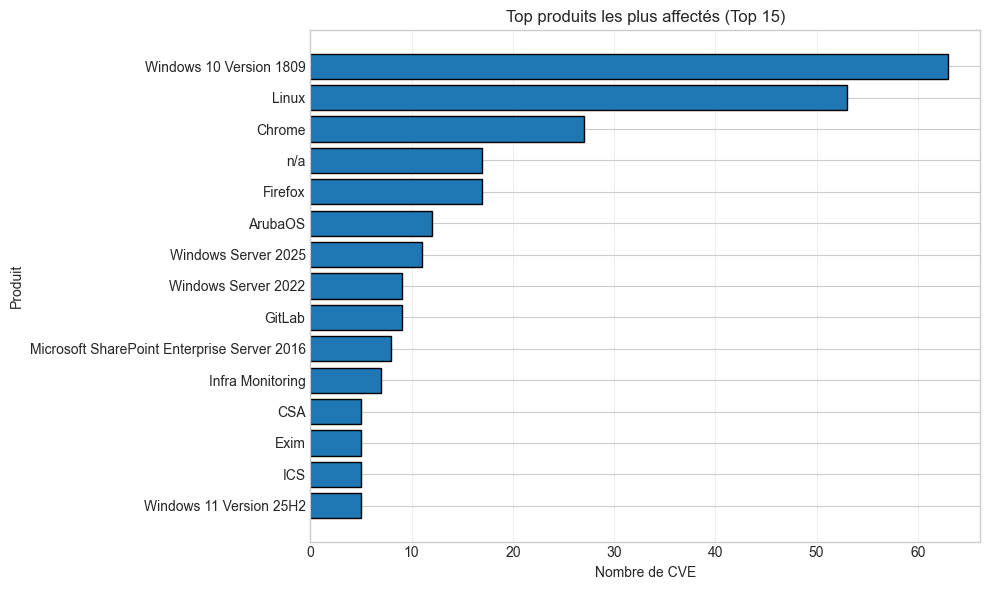

In [80]:
# Graphique 6 : Top produits les plus affectés
df_products = explode_multi_col(df_plot, "Product")
product_counts = df_products["Product"].value_counts().head(15)
if len(product_counts) > 0:
    plt.figure()
    plt.barh(product_counts.index[::-1], product_counts.values[::-1], edgecolor="black")
    plt.title("Top produits les plus affectés (Top 15)")
    plt.xlabel("Nombre de CVE")
    plt.ylabel("Produit")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_06_top_produits_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée de produit disponible")

---

###  Graphique 7 : Corrélation CVSS vs EPSS

Heatmap (carte de chaleur) montrant la corrélation entre le score CVSS (gravité) et le score EPSS (probabilité d'exploitation).
Une corrélation forte indiquerait que les vulnérabilités graves sont aussi plus susceptibles d'être exploitées.

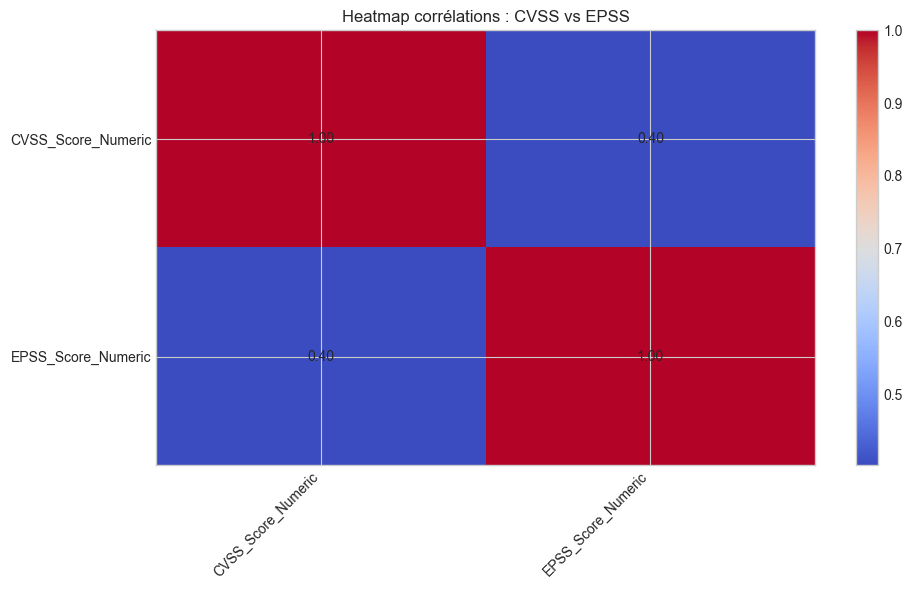

In [81]:
# Graphique 7 : Heatmap des corrélations entre CVSS et EPSS
corr_df = df_plot[["CVSS_Score_Numeric", "EPSS_Score_Numeric"]].dropna()
if len(corr_df) > 1:
    corr = corr_df.corr(numeric_only=True)
    
    plt.figure()
    plt.imshow(corr.values, aspect="auto", cmap='coolwarm')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Heatmap corrélations : CVSS vs EPSS")
    
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            plt.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")
    
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_07_heatmap_correlation_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Données insuffisantes pour la corrélation")

---

### Graphique 8 : Nuage de points CVSS vs EPSS

Scatter plot montrant la relation entre le score CVSS (axe X) et le score EPSS (axe Y) pour chaque CVE.
Permet d'identifier visuellement les CVE critiques (CVSS élevé) avec une forte probabilité d'exploitation (EPSS élevé).

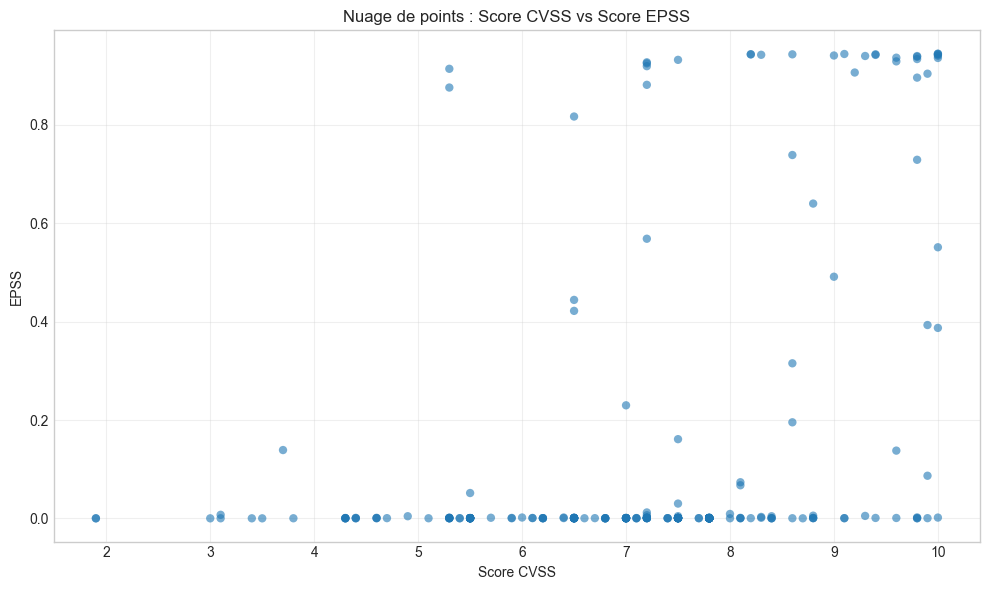

In [82]:
# Graphique 8 : Nuage de points CVSS vs EPSS
scatter_df = df_plot[["CVSS_Score_Numeric", "EPSS_Score_Numeric"]].dropna()
if len(scatter_df) > 0:
    plt.figure()
    plt.scatter(scatter_df["CVSS_Score_Numeric"], scatter_df["EPSS_Score_Numeric"], 
               alpha=0.6, edgecolors="none")
    plt.title("Nuage de points : Score CVSS vs Score EPSS")
    plt.xlabel("Score CVSS")
    plt.ylabel("EPSS")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_08_nuage_points_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée disponible pour le nuage de points")

---

###  Graphique 9 : Distribution des scores CVSS par éditeur

Boxplot (boîte à moustaches) montrant la distribution des scores CVSS pour les 10 principaux éditeurs.
Permet de comparer la gravité moyenne des vulnérabilités entre différents éditeurs.

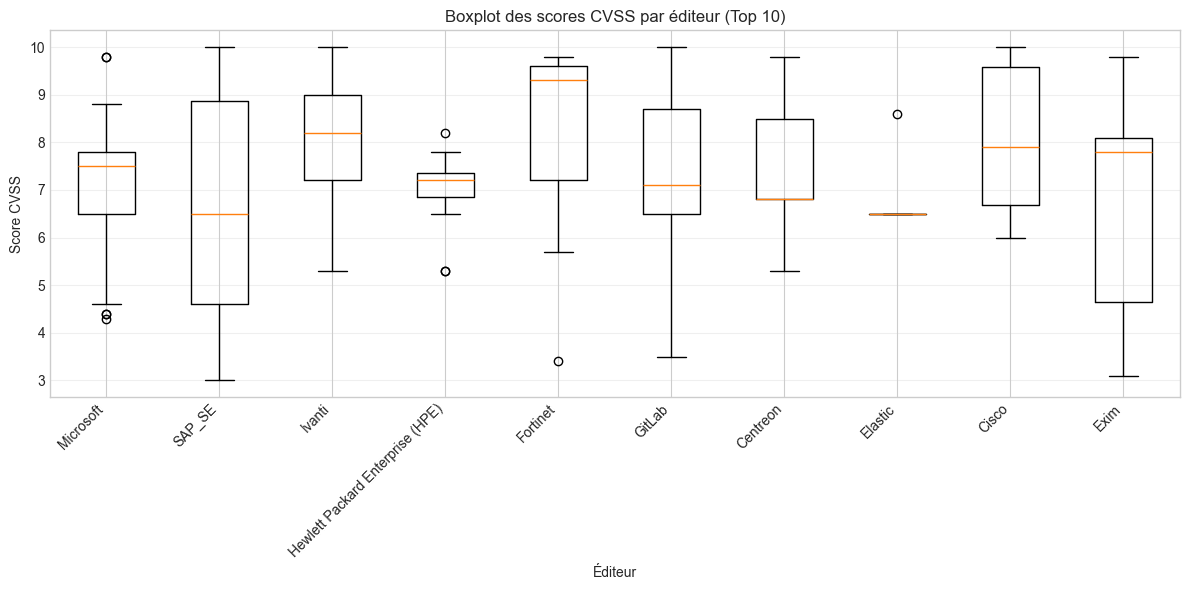

In [ ]:
# Graphique 9 : Boxplot des scores CVSS par éditeur
df_vendors = explode_multi_col(df_plot, "Vendor")
# On garde CVE_ID et CVSS_Score_Numeric avant le merge
df_vendors_cvss = df_vendors[["CVE_ID", "Vendor"]].merge(
    df_plot[["CVE_ID", "CVSS_Score_Numeric"]], on="CVE_ID", how="left"
).dropna(subset=["CVSS_Score_Numeric"])

if len(df_vendors_cvss) > 0:
    top_vendors = df_vendors_cvss["Vendor"].value_counts().head(10).index.tolist()
    box_df = df_vendors_cvss[df_vendors_cvss["Vendor"].isin(top_vendors)]
    
    if len(box_df) > 0:
        data = [box_df[box_df["Vendor"] == v]["CVSS_Score_Numeric"].values for v in top_vendors]
        
        plt.figure(figsize=(12, 6))
        plt.boxplot(data, labels=top_vendors, vert=True, showfliers=True)
        plt.title("Boxplot des scores CVSS par éditeur (Top 10)")
        plt.xlabel("Éditeur")
        plt.ylabel("Score CVSS")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"donnees_crees/graph_10_boxplot_editeurs_{timestamp}.png", dpi=DPI_GRAPHIQUES)
        plt.show()
    else:
        print("Données insuffisantes pour le boxplot")
else:
    print("Aucune donnée disponible pour le boxplot")

---

###  Graphique 10 : Versions les plus fréquemment affectées

Diagramme en barres horizontales des versions de logiciels les plus souvent mentionnées dans les CVE.
Aide à identifier quelles versions nécessitent une mise à jour prioritaire.

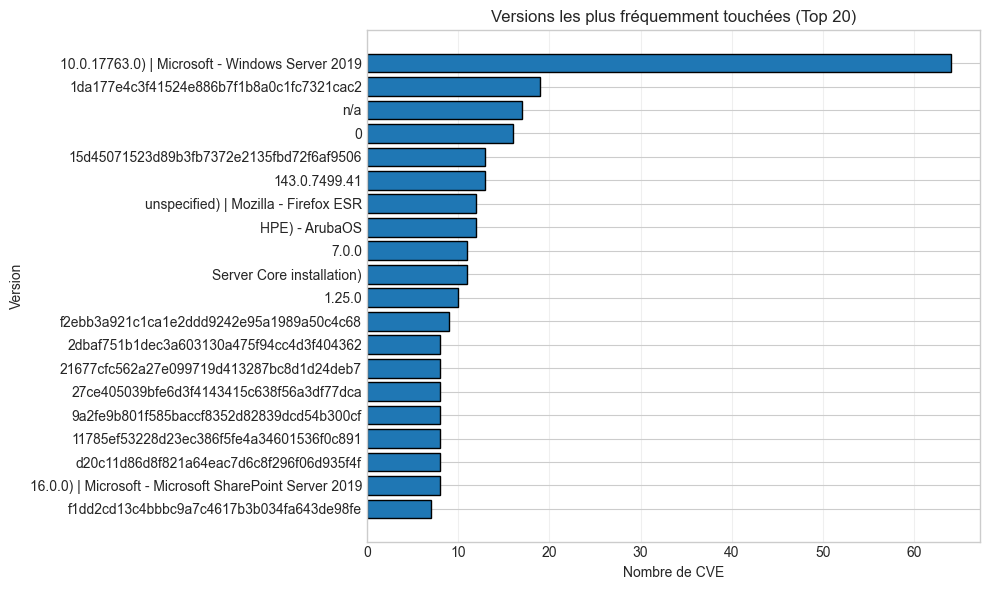

In [ ]:
# Graphique 10 : Versions les plus fréquemment touchées
df_versions = explode_multi_col(df_plot, "Affected_Versions")
ver_counts = df_versions["Affected_Versions"].value_counts().head(20)
if len(ver_counts) > 0:
    plt.figure()
    plt.barh(ver_counts.index[::-1], ver_counts.values[::-1], edgecolor="black")
    plt.title("Versions les plus fréquemment touchées (Top 20)")
    plt.xlabel("Nombre de CVE")
    plt.ylabel("Version")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"donnees_crees/graph_11_versions_affectees_{timestamp}.png", dpi=DPI_GRAPHIQUES)
    plt.show()
else:
    print("Aucune donnée de version disponible")